# Results SL OOD experiment

In [ ]:
# 

/tmp/ipykernel_2122506/3616296916.py:52: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  float_vals = auroc_data.replace("N/A", np.nan).applymap(
/tmp/ipykernel_2122506/3616296916.py:60: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  blues_full = cm.get_cmap("Blues", 256)


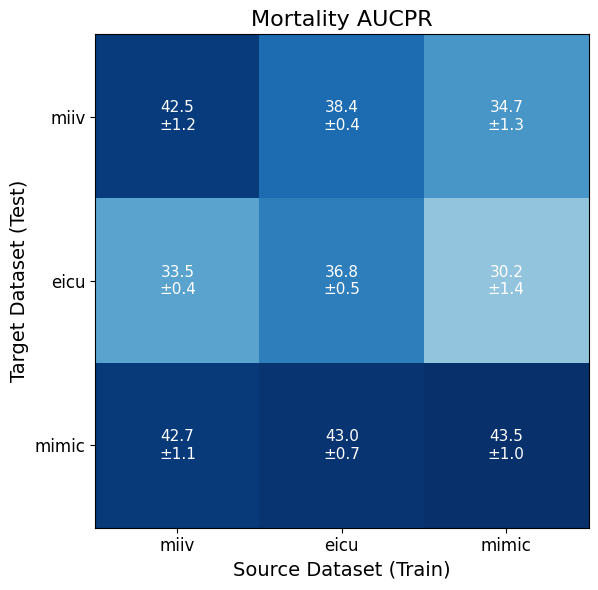

In [25]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import ListedColormap

# === Choose Metric: "AUC" or "PR" or "loss" ===
metric_name = "PR"  # Change this to "PR" or "loss" as needed

# Display names for titles and labels
metric_display_names = {
    "AUC": "AUCROC",
    "PR": "AUCPR",
    "loss": "Loss"
}

display_name = metric_display_names.get(metric_name, metric_name)


# === Step 1: Define input paths ===
paths = {
    "miiv": "/work3/s185395/yaib_logs/miiv/Mortality24/BAT/2025-06-06T13-17-03/repetition_0",
    "eicu": "/work3/s185395/yaib_logs/eicu/Mortality24/BAT/2025-06-06T13-13-48/repetition_0",
    "mimic": "/work3/s185395/yaib_logs/mimic/Mortality24/BAT/2025-06-06T13-12-21/repetition_0",
}

# === Step 2: Load selected metric values ===
auroc_data = pd.DataFrame(index=paths.keys(), columns=paths.keys())

for source, base_path in paths.items():
    for target in paths.keys():
        if source == target:
            json_path = f"{base_path}/mean_result.json"
        else:
            json_path = f"{base_path}/{target}_mean_results.json"

        try:
            with open(json_path, "r") as f:
                metrics = json.load(f)
                mean = metrics[metric_name]["mean"] * 100
                std = metrics[metric_name]["std"] * 100
                auroc_data.loc[target, source] = f"{mean:.1f}\n±{std:.1f}"
        except Exception as e:
            auroc_data.loc[target, source] = "N/A"
            print(f"⚠️ Failed to load: {json_path}\n{e}")

# === Step 3: Plot heatmap ===
fig, ax = plt.subplots(figsize=(8, 6))
heatmap_values = auroc_data.replace("N/A", np.nan)

float_vals = auroc_data.replace("N/A", np.nan).applymap(
    lambda x: float(x.split("±")[0]) if isinstance(x, str) and "±" in x else np.nan
)

vmin = float_vals.min().min()
vmax = float_vals.max().max()

# Create a truncated "Blues" colormap, keeping only the stronger blue range
blues_full = cm.get_cmap("Blues", 256)
blues_trimmed = ListedColormap(blues_full(np.linspace(0.4, 1.0, 256)))  # avoid 0.0–0.2 (white)

# Draw heatmap
im = ax.imshow(float_vals.values.astype(float), cmap=blues_trimmed, vmin=vmin, vmax=vmax)

# === 🔄 Always use white text
for i in range(len(auroc_data)):
    for j in range(len(auroc_data.columns)):
        value = auroc_data.iloc[i, j]
        if isinstance(value, str) and "±" in value:
            mean, std = value.split("±")
            text = f"{mean.strip()}\n±{std.strip()}"
        else:
            text = value
        ax.text(
            j, i, text,
            ha="center", va="center",
            color="white",  # 👈 always white
            fontsize=11
        )

# Set ticks and labels
ax.set_xticks(np.arange(len(paths)))
ax.set_yticks(np.arange(len(paths)))
ax.set_xticklabels(paths.keys(), fontsize=12)
ax.set_yticklabels(paths.keys(), fontsize=12)
ax.set_xlabel("Source Dataset (Train)", fontsize=14)
ax.set_ylabel("Target Dataset (Test)", fontsize=14)
ax.set_title(f"Mortality {metric_display_names[metric_name]}", fontsize=16)


plt.tight_layout()
plt.show()


In [10]:
import pandas as pd

# Define dataset sizes
sizes = [100, 500, 1000, 2000, 3000, 5000, 7000, 9000, 9506]

# Define performance metrics for each model
from_scratch = {
    "Loss": [0.3596, 0.3706, 0.3183, 0.3146, 0.3106, 0.3018, 0.2951, 0.2857],
    "AUROC": [0.6625, 0.6249, 0.7643, 0.7752, 0.7797, 0.8059, 0.8086, 0.8242],
    "AUPRC": [0.2068, 0.1756, 0.3084, 0.3440, 0.3592, 0.3998, 0.3860, 0.4210]
}

fine_tuned = {
    "Loss": [0.7596, 0.3195, 0.3072, 0.2935, 0.3014, 0.2839, 0.2839, 0.2789],
    "AUROC": [0.5418, 0.7541, 0.7769, 0.8039, 0.8165, 0.8157, 0.8157, 0.8387],
    "AUPRC": [0.1649, 0.3278, 0.3670, 0.3996, 0.4190, 0.4359, 0.4359, 0.4455]
}

# Create a DataFrame
df = pd.DataFrame({
    "Size": sizes,
    "Loss_from_scratch": from_scratch["Loss"],
    "AUROC_from_scratch": from_scratch["AUROC"],
    "AUPRC_from_scratch": from_scratch["AUPRC"],
    "Loss_fine_tuned": fine_tuned["Loss"],
    "AUROC_fine_tuned": fine_tuned["AUROC"],
    "AUPRC_fine_tuned": fine_tuned["AUPRC"]
})



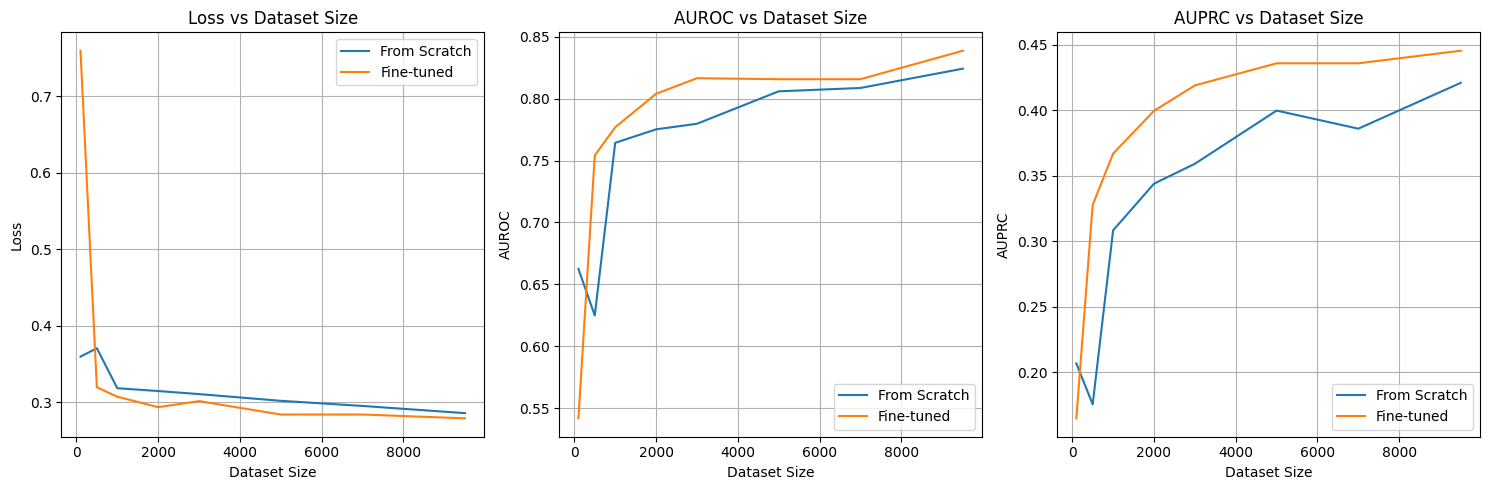

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

# -------- Loss Plot --------
plt.subplot(1, 3, 1)
plt.plot(df['Size'], df['Loss_from_scratch'], label='From Scratch')
plt.plot(df['Size'], df['Loss_fine_tuned'], label='Fine-tuned')
plt.xlabel('Dataset Size')
plt.ylabel('Loss')
plt.title('Loss vs Dataset Size')
plt.legend()
plt.grid(True)

# -------- AUROC Plot --------
plt.subplot(1, 3, 2)
plt.plot(df['Size'], df['AUROC_from_scratch'], label='From Scratch')
plt.plot(df['Size'], df['AUROC_fine_tuned'], label='Fine-tuned')
plt.xlabel('Dataset Size')
plt.ylabel('AUROC')
plt.title('AUROC vs Dataset Size')
plt.legend()
plt.grid(True)

# -------- AUPRC Plot --------
plt.subplot(1, 3, 3)
plt.plot(df['Size'], df['AUPRC_from_scratch'], label='From Scratch')
plt.plot(df['Size'], df['AUPRC_fine_tuned'], label='Fine-tuned')
plt.xlabel('Dataset Size')
plt.ylabel('AUPRC')
plt.title('AUPRC vs Dataset Size')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


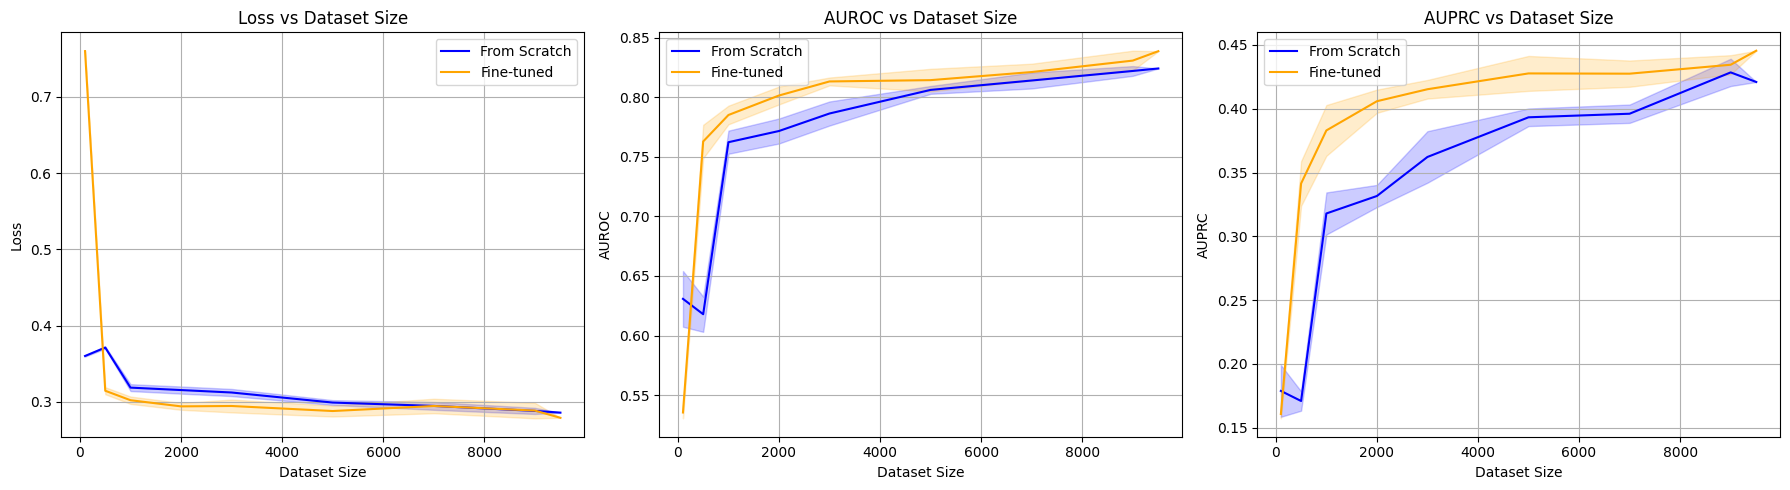

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Define dataset sizes
sizes = [100, 500, 1000, 2000, 3000, 5000, 7000, 9000, 9506]

# From Scratch metrics


scratch = {
    "Loss_mean": [0.3600, 0.3711, 0.3185, 0.3153, 0.3121, 0.2989, 0.2945, 0.28796, 0.2857],
    "Loss_sd":   [0.0008, 0.0014, 0.0045, 0.0047, 0.0047, 0.0032, 0.0051, 0.00404, 0.0],
    "AUROC_mean": [0.6308, 0.6179, 0.7623, 0.7717, 0.7864, 0.8062, 0.8141, 0.8221, 0.8242],
    "AUROC_sd":   [0.0234, 0.0148, 0.0097, 0.0105, 0.0101, 0.0033, 0.0067, 0.0041, 0.0],
    "AUPRC_mean": [0.1788, 0.1709, 0.3179, 0.3316, 0.3622, 0.3933, 0.3961, 0.4285, 0.4210],
    "AUPRC_sd":   [0.0203, 0.0076, 0.0165, 0.0087, 0.0202, 0.0069, 0.0072, 0.0107, 0.0],
}

# Fine-Tuned metrics
finetuned = {
    "Loss_mean": [0.7600, 0.3144, 0.30196, 0.2939, 0.2944, 0.2878, 0.2944, 0.2884, 0.2789],
    "Loss_sd":   [0.0005, 0.0046, 0.00483, 0.0045, 0.0084, 0.0072, 0.0095, 0.0102, 0.0],
    "AUROC_mean": [0.5354, 0.7629, 0.78514, 0.8015, 0.8133, 0.8144, 0.8212, 0.8308, 0.8387],
    "AUROC_sd":   [0.0049, 0.0140, 0.00782, 0.0075, 0.0033, 0.0095, 0.0070, 0.0083, 0.0],
    "AUPRC_mean": [0.1607, 0.3414, 0.3830, 0.4059, 0.4153, 0.4277, 0.4275, 0.4345, 0.4455],
    "AUPRC_sd":   [0.0034, 0.0175, 0.0199, 0.0091, 0.0073, 0.0137, 0.0103, 0.0075, 0.0],
}

# Build DataFrame
df = pd.DataFrame({
    "Size": sizes,
    **{f"{k}_scratch": v for k, v in scratch.items()},
    **{f"{k}_finetuned": v for k, v in finetuned.items()},
})

# Plotting
plt.figure(figsize=(18, 5))

metrics = ['Loss', 'AUROC', 'AUPRC']
for i, metric in enumerate(metrics, 1):
    plt.subplot(1, 3, i)
    
    # Plot mean line
    plt.plot(df['Size'], df[f"{metric}_mean_scratch"], label='From Scratch', color='blue')
    plt.fill_between(df['Size'], 
                     pd.Series(df[f"{metric}_mean_scratch"]) - pd.Series(df[f"{metric}_sd_scratch"]), 
                     pd.Series(df[f"{metric}_mean_scratch"]) + pd.Series(df[f"{metric}_sd_scratch"]),
                     color='blue', alpha=0.2)
    
    plt.plot(df['Size'], df[f"{metric}_mean_finetuned"], label='Fine-tuned', color='orange')
    plt.fill_between(df['Size'], 
                     pd.Series(df[f"{metric}_mean_finetuned"]) - pd.Series(df[f"{metric}_sd_finetuned"]), 
                     pd.Series(df[f"{metric}_mean_finetuned"]) + pd.Series(df[f"{metric}_sd_finetuned"]),
                     color='orange', alpha=0.2)
    
    plt.xlabel('Dataset Size')
    plt.ylabel(metric)
    plt.title(f'{metric} vs Dataset Size')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()


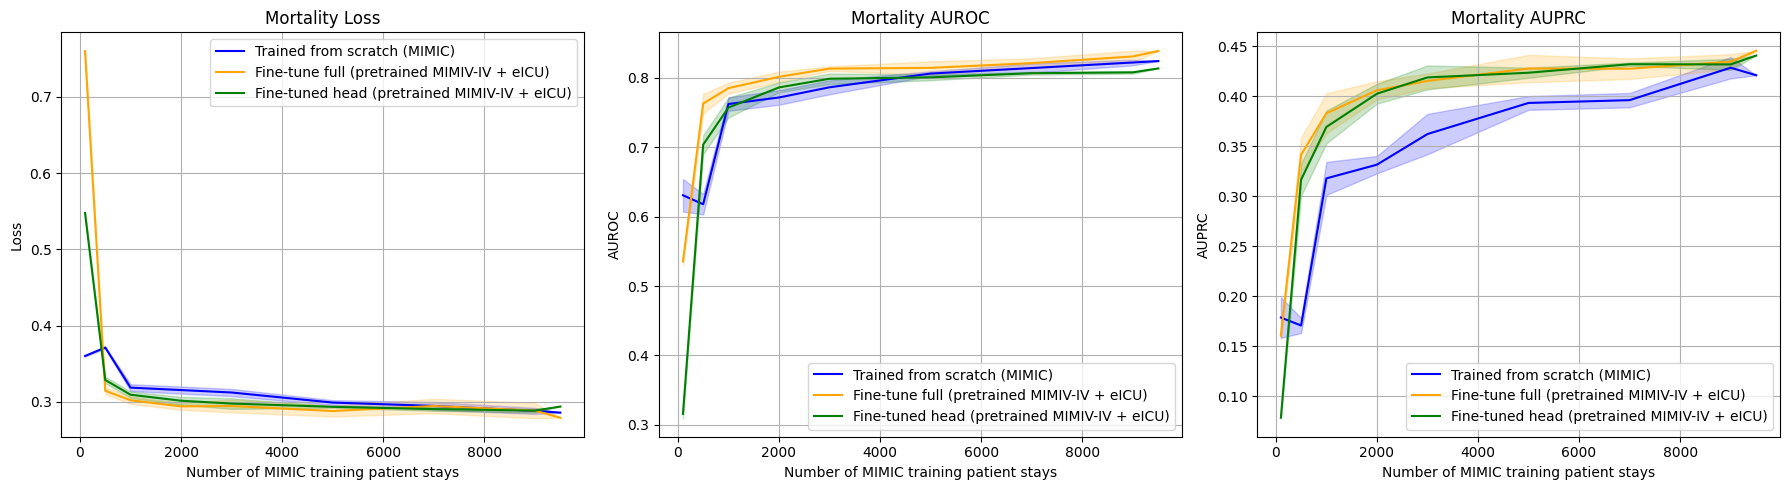

In [207]:
import pandas as pd
import matplotlib.pyplot as plt

# Define dataset sizes
sizes = [100, 500, 1000, 2000, 3000, 5000, 7000, 9000, 9506]

# From Scratch metrics
scratch = {
    "Loss_mean": [0.3600, 0.3711, 0.3185, 0.3153, 0.3121, 0.2989, 0.2945, 0.28796, 0.2857],
    "Loss_sd":   [0.0008, 0.0014, 0.0045, 0.0047, 0.0047, 0.0032, 0.0051, 0.00404, 0.0],
    "AUROC_mean": [0.6308, 0.6179, 0.7623, 0.7717, 0.7864, 0.8062, 0.8141, 0.8221, 0.8242],
    "AUROC_sd":   [0.0234, 0.0148, 0.0097, 0.0105, 0.0101, 0.0033, 0.0067, 0.0041, 0.0],
    "AUPRC_mean": [0.1788, 0.1709, 0.3179, 0.3316, 0.3622, 0.3933, 0.3961, 0.4285, 0.4210],
    "AUPRC_sd":   [0.0203, 0.0076, 0.0165, 0.0087, 0.0202, 0.0069, 0.0072, 0.0107, 0.0],
}

# Fine-Tuned metrics
finetuned = {
    "Loss_mean": [0.7600, 0.3144, 0.30196, 0.2939, 0.2944, 0.2878, 0.2944, 0.2884, 0.2789],
    "Loss_sd":   [0.0005, 0.0046, 0.00483, 0.0045, 0.0084, 0.0072, 0.0095, 0.0102, 0.0],
    "AUROC_mean": [0.5354, 0.7629, 0.78514, 0.8015, 0.8133, 0.8144, 0.8212, 0.8308, 0.8387],
    "AUROC_sd":   [0.0049, 0.0140, 0.00782, 0.0075, 0.0033, 0.0095, 0.0070, 0.0083, 0.0],
    "AUPRC_mean": [0.1607, 0.3414, 0.3830, 0.4059, 0.4153, 0.4277, 0.4275, 0.4345, 0.4455],
    "AUPRC_sd":   [0.0034, 0.0175, 0.0199, 0.0091, 0.0073, 0.0137, 0.0103, 0.0075, 0.0],
}

# Fine-Tuned Head metrics
finetuned_head = {
    "Loss_mean": [0.5475, 0.3285, 0.3092, 0.3013, 0.2976, 0.2933, 0.2904, 0.2883, 0.2937],
    "Loss_sd":   [0.0017, 0.0043, 0.0042, 0.0051, 0.0070, 0.0012, 0.0023, 0.0023, 0.0],
    "AUROC_mean": [0.3158, 0.7038, 0.7572, 0.7862, 0.7987, 0.8007, 0.8067, 0.8079, 0.8136],
    "AUROC_sd":   [0.0064, 0.0136, 0.0143, 0.0072, 0.0076, 0.0042, 0.0021, 0.0018, 0.0],
    "AUPRC_mean": [0.0788, 0.3166, 0.3693, 0.4025, 0.4188, 0.4235, 0.4320, 0.4318, 0.4407],
    "AUPRC_sd":   [0.0007, 0.0161, 0.0164, 0.0099, 0.0120, 0.0051, 0.0017, 0.0055, 0.0],
}

# Combine all into a DataFrame
df = pd.DataFrame({
    "Size": sizes,
    **{f"{k}_scratch": v for k, v in scratch.items()},
    **{f"{k}_finetuned": v for k, v in finetuned.items()},
    **{f"{k}_finetuned_head": v for k, v in finetuned_head.items()},
})


# Plotting
plt.figure(figsize=(18, 5))
metrics = ['Loss', 'AUROC', 'AUPRC']

for i, metric in enumerate(metrics, 1):
    plt.subplot(1, 3, i)
    
    # Plot From Scratch
    plt.plot(df['Size'], df[f"{metric}_mean_scratch"], label='Trained from scratch (MIMIC)', color='blue')
    plt.fill_between(df['Size'], 
                     df[f"{metric}_mean_scratch"] - df[f"{metric}_sd_scratch"],
                     df[f"{metric}_mean_scratch"] + df[f"{metric}_sd_scratch"],
                     color='blue', alpha=0.2)
    
    # Plot Fine-tuned
    plt.plot(df['Size'], df[f"{metric}_mean_finetuned"], label='Fine-tune full (pretrained MIMIV-IV + eICU)', color='orange')
    plt.fill_between(df['Size'], 
                     df[f"{metric}_mean_finetuned"] - df[f"{metric}_sd_finetuned"],
                     df[f"{metric}_mean_finetuned"] + df[f"{metric}_sd_finetuned"],
                     color='orange', alpha=0.2)
    
    # Plot Fine-tuned Head
    plt.plot(df['Size'], df[f"{metric}_mean_finetuned_head"], label='Fine-tuned head (pretrained MIMIV-IV + eICU)', color='green')
    plt.fill_between(df['Size'], 
                     df[f"{metric}_mean_finetuned_head"] - df[f"{metric}_sd_finetuned_head"],
                     df[f"{metric}_mean_finetuned_head"] + df[f"{metric}_sd_finetuned_head"],
                     color='green', alpha=0.2)

    plt.xlabel('Number of MIMIC training patient stays')
    plt.ylabel(metric)
    plt.title(f'Mortality {metric}')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()


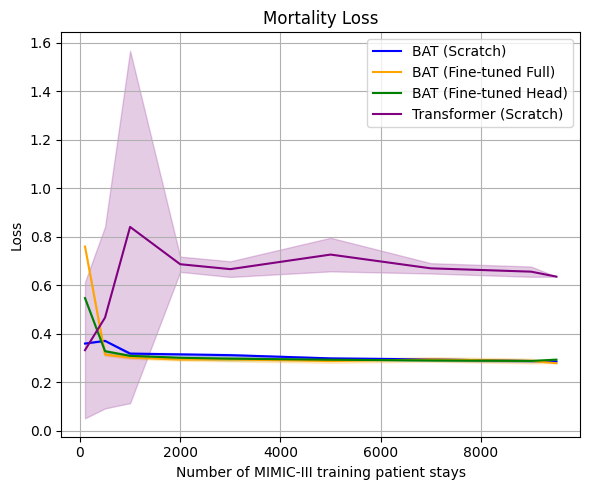

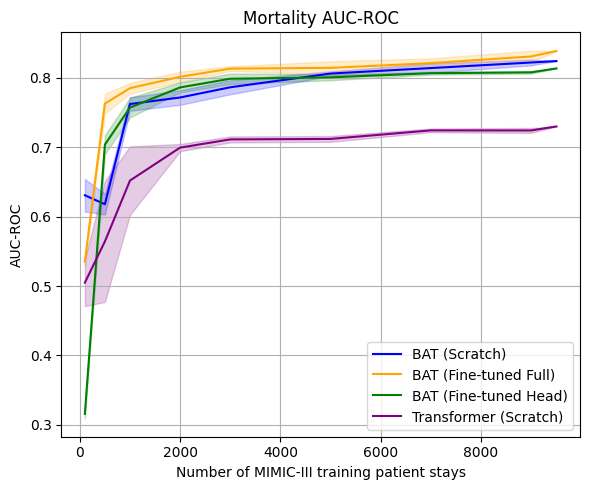

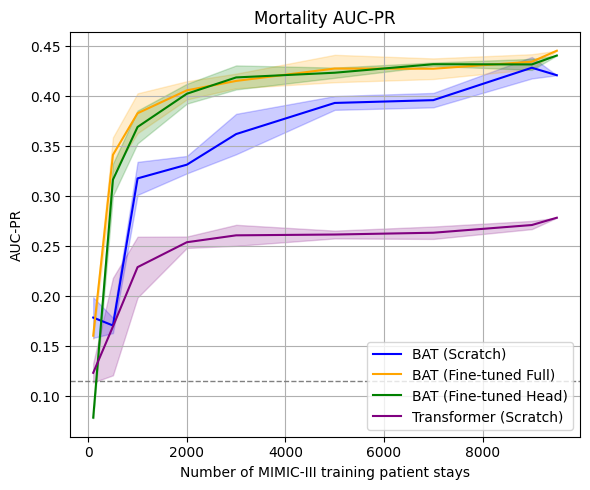

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Define dataset sizes
sizes = [100, 500, 1000, 2000, 3000, 5000, 7000, 9000, 9506]

# From Scratch metrics
scratch = {
    "Loss_mean": [0.3600, 0.3711, 0.3185, 0.3153, 0.3121, 0.2989, 0.2945, 0.28796, 0.2857],
    "Loss_sd":   [0.0008, 0.0014, 0.0045, 0.0047, 0.0047, 0.0032, 0.0051, 0.00404, 0.0],
    "AUC_ROC_mean": [0.6308, 0.6179, 0.7623, 0.7717, 0.7864, 0.8062, 0.8141, 0.8221, 0.8242],
    "AUC_ROC_sd":   [0.0234, 0.0148, 0.0097, 0.0105, 0.0101, 0.0033, 0.0067, 0.0041, 0.0],
    "AUC_PR_mean": [0.1788, 0.1709, 0.3179, 0.3316, 0.3622, 0.3933, 0.3961, 0.4285, 0.4210],
    "AUC_PR_sd":   [0.0203, 0.0076, 0.0165, 0.0087, 0.0202, 0.0069, 0.0072, 0.0107, 0.0],
}

# Fine-Tuned metrics
finetuned = {
    "Loss_mean": [0.7600, 0.3144, 0.30196, 0.2939, 0.2944, 0.2878, 0.2944, 0.2884, 0.2789],
    "Loss_sd":   [0.0005, 0.0046, 0.00483, 0.0045, 0.0084, 0.0072, 0.0095, 0.0102, 0.0],
    "AUC_ROC_mean": [0.5354, 0.7629, 0.78514, 0.8015, 0.8133, 0.8144, 0.8212, 0.8308, 0.8387],
    "AUC_ROC_sd":   [0.0049, 0.0140, 0.00782, 0.0075, 0.0033, 0.0095, 0.0070, 0.0083, 0.0],
    "AUC_PR_mean": [0.1607, 0.3414, 0.3830, 0.4059, 0.4153, 0.4277, 0.4275, 0.4345, 0.4455],
    "AUC_PR_sd":   [0.0034, 0.0175, 0.0199, 0.0091, 0.0073, 0.0137, 0.0103, 0.0075, 0.0],
}

# Fine-Tuned Head metrics
finetuned_head = {
    "Loss_mean": [0.5475, 0.3285, 0.3092, 0.3013, 0.2976, 0.2933, 0.2904, 0.2883, 0.2937],
    "Loss_sd":   [0.0017, 0.0043, 0.0042, 0.0051, 0.0070, 0.0012, 0.0023, 0.0023, 0.0],
    "AUC_ROC_mean": [0.3158, 0.7038, 0.7572, 0.7862, 0.7987, 0.8007, 0.8067, 0.8079, 0.8136],
    "AUC_ROC_sd":   [0.0064, 0.0136, 0.0143, 0.0072, 0.0076, 0.0042, 0.0021, 0.0018, 0.0],
    "AUC_PR_mean": [0.0788, 0.3166, 0.3693, 0.4025, 0.4188, 0.4235, 0.4320, 0.4318, 0.4407],
    "AUC_PR_sd":   [0.0007, 0.0161, 0.0164, 0.0099, 0.0120, 0.0051, 0.0017, 0.0055, 0.0],
}

# Baseline metrics
baseline = {
    "Loss_mean": [0.3327, 0.4669, 0.8407, 0.6869, 0.6667, 0.7267, 0.6700, 0.6563, 0.6358],
    "Loss_sd":   [0.2810, 0.3744, 0.7263, 0.0315, 0.0323, 0.0692, 0.0213, 0.0211, 0.0000],
    "AUC_ROC_mean": [0.5049, 0.5643, 0.6520, 0.6995, 0.7113, 0.7120, 0.7243, 0.7242, 0.7300],
    "AUC_ROC_sd":   [0.0338, 0.0871, 0.0493, 0.0052, 0.0043, 0.0042, 0.0027, 0.0035, 0.0000],
    "AUC_PR_mean": [0.1236, 0.1698, 0.2292, 0.2541, 0.2610, 0.2618, 0.2636, 0.2713, 0.2786],
    "AUC_PR_sd":   [0.0096, 0.0487, 0.0304, 0.0057, 0.0105, 0.0039, 0.0062, 0.0041, 0.0000],
}

# Combine all into a DataFrame
df = pd.DataFrame({
    "Size": sizes,
    **{f"{k}_scratch": v for k, v in scratch.items()},
    **{f"{k}_finetuned": v for k, v in finetuned.items()},
    **{f"{k}_finetuned_head": v for k, v in finetuned_head.items()},
    **{f"{k}_baseline": v for k, v in baseline.items()},
})

# Plot each metric in a separate figure
metrics = ['Loss', 'AUC_ROC', 'AUC_PR']

for metric in metrics:
    plt.figure(figsize=(6, 5))
    
    if metric == 'AUC_PR':
        plt.axhline(y=0.1158, color='grey', linestyle='--', linewidth=1)
    
    # From Scratch
    plt.plot(df['Size'], df[f"{metric}_mean_scratch"], label='BAT (Scratch)', color='blue')
    plt.fill_between(df['Size'], 
                     df[f"{metric}_mean_scratch"] - df[f"{metric}_sd_scratch"],
                     df[f"{metric}_mean_scratch"] + df[f"{metric}_sd_scratch"],
                     color='blue', alpha=0.2)
    
    # Fine-tuned
    plt.plot(df['Size'], df[f"{metric}_mean_finetuned"], label='BAT (Fine-tuned Full)', color='orange')
    plt.fill_between(df['Size'], 
                     df[f"{metric}_mean_finetuned"] - df[f"{metric}_sd_finetuned"],
                     df[f"{metric}_mean_finetuned"] + df[f"{metric}_sd_finetuned"],
                     color='orange', alpha=0.2)
    
    # Fine-tuned Head
    plt.plot(df['Size'], df[f"{metric}_mean_finetuned_head"], label='BAT (Fine-tuned Head)', color='green')
    plt.fill_between(df['Size'], 
                     df[f"{metric}_mean_finetuned_head"] - df[f"{metric}_sd_finetuned_head"],
                     df[f"{metric}_mean_finetuned_head"] + df[f"{metric}_sd_finetuned_head"],
                     color='green', alpha=0.2)

    # Baseline
    plt.plot(df['Size'], df[f"{metric}_mean_baseline"], label='Transformer (Scratch)', color='purple')
    plt.fill_between(df['Size'], 
                     df[f"{metric}_mean_baseline"] - df[f"{metric}_sd_baseline"],
                     df[f"{metric}_mean_baseline"] + df[f"{metric}_sd_baseline"],
                     color='purple', alpha=0.2)

    plt.xlabel('Number of MIMIC-III training patient stays')
    plt.ylabel(metric.replace("_", "-"))
    plt.title(f'Mortality {metric.replace("_", "-")}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()